# Testing out Bayesian Optimization with a GP
Use an "online" setup, leading to eventual comparison with RF

In [281]:
import sys
import os
import time
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset

In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from bayes_opt import BayesianOptimization, acquisition
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [283]:
input1 = ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean"],
input_min = ["inj_mbar_mean", "bias_v_mean"]

config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": input_min,
    "output_columns": ["fcv1_i_mean"],
}

dataset = VenusDataset(**config)
df = dataset.df
print(df['run_id'].unique())

['00' '01' '02' '03' '04' '05' '06' '08' '08a' '08b' '08c' '08d' '09' '10'
 '10b' '11' '11b' '12' '13' '14']


In [284]:
import pandas as pd

def get_run_data(df: pd.DataFrame, run_id_value) -> pd.DataFrame:
    """
    Returns a subset of the dataframe for which the 'run_id' column matches the given run_id_value.
    """
    return df[df['run_id'] == run_id_value].copy()

def select_features(df: pd.DataFrame, input_columns: list, output_column: str):
    """
    Returns a tuple (X, y) containing only the specified input columns and output column.
    """
    X = df[input_columns].copy()
    y = df[output_column].copy()
    return X, y

In [285]:
def train_validation_split(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2, random_state: int = 42):
    """
    Splits the data into training and holdout (validation) sets.
    """
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def find_nearest_neighbor(candidate: dict, X: pd.DataFrame, y, input_columns: list):
    """
    Given a candidate point (as a dict), finds the closest data point in X (using Euclidean distance)
    and returns its corresponding target value from y.
    
    This function now works whether y is a Pandas Series or a NumPy array.
    """
    candidate_vector = np.array([candidate[col] for col in input_columns])
    distances = np.linalg.norm(X[input_columns].values - candidate_vector, axis=1)
    idx = np.argmin(distances)
    
    # Check if y is a Pandas Series (has iloc) or a NumPy array
    if hasattr(y, "iloc"):
        return y.iloc[idx]
    else:
        return y[idx]


def evaluate_holdout(optimizer, X_holdout: pd.DataFrame, y_holdout: pd.Series, input_columns: list) -> float:
    """
    Uses the current surrogate model (Gaussian Process) to predict on the holdout set
    and returns the R² score.
    """
    # Ensure that X_holdout has the same column order as the optimizer's pbounds
    X_holdout_array = X_holdout[input_columns].values
    # optimizer.gp is the internal Gaussian process that gets updated with each register call
    y_pred = optimizer._gp.predict(X_holdout_array)
    return r2_score(y_holdout, y_pred)

In [286]:
import numpy as np
from scipy.stats import norm
from bayes_opt import acquisition

class HybridAcquisition(acquisition.AcquisitionFunction):
    def __init__(self, weight_ei=0.5, xi=0.0, kappa=2.5, random_state=None):
        """
        HybridAcquisitionUCB_EI combines Expected Improvement (EI) and Upper Confidence Bound (UCB).
        
        Args:
            weight_ei (float): Weight for the EI component (0 to 1). The UCB component is weighted as (1 - weight_ei).
            xi (float): Exploration parameter for EI.
            kappa (float): Exploration parameter for UCB.
            random_state: Random state for reproducibility.
        """
        super().__init__(random_state)
        self.weight_ei = weight_ei
        self.xi = xi
        self.kappa = kappa

    def base_acq(self, mean, std, f_best):
        """
        Computes the weighted combination of Expected Improvement (EI) and Upper Confidence Bound (UCB).
        
        Args:
            mean (np.array): Predicted means at candidate points.
            std (np.array): Predicted standard deviations at candidate points.
            f_best (float): The best observed target value so far.
            
        Returns:
            np.array: Hybrid acquisition values.
        """
        # Calculate Expected Improvement (EI)
        improvement = mean - f_best - self.xi
        # Avoid division by zero: replace zeros in std with a tiny positive number.
        std_safe = np.where(std == 0, 1e-8, std)
        Z = improvement / std_safe
        ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)
        # If std is zero, no improvement can be expected.
        ei[std == 0] = 0.0

        # Calculate Upper Confidence Bound (UCB)
        ucb = mean + self.kappa * std

        # Return a weighted combination of EI and UCB.
        return self.weight_ei * ei + (1 - self.weight_ei) * ucb

    def _get_acq(self, gp, constraint=None):
        """
        Returns a function that computes the hybrid acquisition value for candidate points.
        """
        # Determine the dimensionality of the input space.
        dim = gp.X_train_.shape[1]
        # f_best is the best target observed so far.
        f_best = np.max(gp.y_train_)
        
        def acq(x):
            x = x.reshape(-1, dim)
            with np.errstate(invalid='ignore'):
                mean, std = gp.predict(x, return_std=True)
            return self.base_acq(mean, std, f_best)
        
        return acq

    def suggest(self, gp, target_space, n_random=10000, n_l_bfgs_b=10, fit_gp: bool = True):
        # Optionally, you can override suggest if needed.
        return super().suggest(gp, target_space, n_random, n_l_bfgs_b, fit_gp)


In [287]:
# Assume 'df' is your full dataframe with all dataset columns already loaded.
# Define input and output columns
# input_columns = ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean"]
input_columns = ["inj_mbar_mean", "bias_v_mean"]
output_column = "fcv1_i_mean"

# Set the run ID you want to work with (change as needed)
RUN_ID = "00"

# Filter the dataframe for the selected run
run_df = get_run_data(df, RUN_ID)

# Select features and target
X, y = select_features(run_df, input_columns, output_column)

# Split the data into training (for simulation) and holdout (for performance evaluation)
X_train, X_holdout, y_train, y_holdout = train_validation_split(X, y, test_size=0.2, random_state=42)

# Standardize the input features based on the training set only
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train = pd.DataFrame(scaler_X.fit_transform(X_train),
                              columns=input_columns,
                              index=X_train.index)
X_holdout = pd.DataFrame(scaler_X.transform(X_holdout),
                                columns=input_columns,
                                index=X_holdout.index)

# Optionally, standardize the target variable if desired
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_holdout = scaler_y.transform(y_holdout.values.reshape(-1, 1)).flatten()

# Define parameter bounds in the standardized space using the training set
pbounds = {col: (X_train[col].min(), X_train[col].max()) for col in input_columns}

print("Standardized parameter bounds:")
print(pbounds)


Standardized parameter bounds:
{'inj_mbar_mean': (-2.0867780283503645, 2.6015991740520112), 'bias_v_mean': (-1.4422185485766883, 2.2773649719888156)}


In [288]:
import numpy as np
from tqdm import tqdm
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt

# Define sweep values:
weight_ei_values = [0.0, 0.25, 0.5, 0.75, 1.0]
xi_values = [0.0, 0.05, 0.1, 0.2, 0.5]
kappa_values = [1.0, 2.0, 2.5, 3.0, 5.0]

# Fixed parameters for the other sweeps:
fixed_xi = 0.1
fixed_kappa = 2.5
fixed_weight_ei = 0.7

# Optimization settings:
n_initial = 50  # Pre-register 50 random points
n_iterations = 500

# Dictionaries to store results.
results_weight = {}
results_xi = {}
results_kappa = {}

# ---- Sweep over weight_ei ----
print("Sweeping over weight_ei values...")
for w in weight_ei_values:
    print(f"\nRunning optimization for weight_ei = {w}")
    
    # Instantiate the hybrid acquisition function with the current weight,
    # while keeping xi and kappa fixed.
    hybrid_acq = HybridAcquisition(weight_ei=w, xi=fixed_xi, kappa=fixed_kappa, random_state=42)
    
    # Create a fresh optimizer instance.
    optimizer = BayesianOptimization(
        f=None,  # Manual registration
        pbounds=pbounds,
        verbose=0,
        random_state=42,
        acquisition_function=hybrid_acq
    )
    
    # Pre-register n_initial random points.
    for i in range(n_initial):
        candidate = {col: np.random.uniform(low=pbounds[col][0], high=pbounds[col][1]) for col in input_columns}
        target = find_nearest_neighbor(candidate, X_train, y_train, input_columns)
        optimizer.register(params=candidate, target=target)
    
    iterations = []
    r2_scores = []
    for i in tqdm(range(n_iterations), desc=f"weight_ei={w} Iterations", unit="iter"):
        next_point = optimizer.suggest()
        target = find_nearest_neighbor(next_point, X_train, y_train, input_columns)
        optimizer.register(params=next_point, target=target)
        try:
            r2 = evaluate_holdout(optimizer, X_holdout, y_holdout, input_columns)
        except Exception:
            r2 = np.nan
        iterations.append(i + 1)
        r2_scores.append(r2)
    results_weight[w] = (iterations, r2_scores)
    print(f"Best observed parameters for weight_ei={w}: {optimizer.max}")

# ---- Sweep over xi ----
print("\nSweeping over xi values...")
for xi_val in xi_values:
    print(f"\nRunning optimization for xi = {xi_val}")
    
    # Instantiate the hybrid acquisition with current xi, fixed weight_ei and kappa.
    hybrid_acq = HybridAcquisition(weight_ei=fixed_weight_ei, xi=xi_val, kappa=fixed_kappa, random_state=42)
    
    optimizer = BayesianOptimization(
        f=None,
        pbounds=pbounds,
        verbose=0,
        random_state=42,
        acquisition_function=hybrid_acq
    )
    
    # Pre-register initial random points.
    for i in range(n_initial):
        candidate = {col: np.random.uniform(low=pbounds[col][0], high=pbounds[col][1]) for col in input_columns}
        target = find_nearest_neighbor(candidate, X_train, y_train, input_columns)
        optimizer.register(params=candidate, target=target)
    
    iterations = []
    r2_scores = []
    for i in tqdm(range(n_iterations), desc=f"xi={xi_val} Iterations", unit="iter"):
        next_point = optimizer.suggest()
        target = find_nearest_neighbor(next_point, X_train, y_train, input_columns)
        optimizer.register(params=next_point, target=target)
        try:
            r2 = evaluate_holdout(optimizer, X_holdout, y_holdout, input_columns)
        except Exception:
            r2 = np.nan
        iterations.append(i + 1)
        r2_scores.append(r2)
    results_xi[xi_val] = (iterations, r2_scores)
    print(f"Best observed parameters for xi={xi_val}: {optimizer.max}")

# ---- Sweep over kappa ----
print("\nSweeping over kappa values...")
for k in kappa_values:
    print(f"\nRunning optimization for kappa = {k}")
    
    # Instantiate the hybrid acquisition with current kappa, fixed weight_ei and xi.
    hybrid_acq = HybridAcquisition(weight_ei=fixed_weight_ei, xi=fixed_xi, kappa=k, random_state=42)
    
    optimizer = BayesianOptimization(
        f=None,
        pbounds=pbounds,
        verbose=0,
        random_state=42,
        acquisition_function=hybrid_acq
    )
    
    # Pre-register initial random points.
    for i in range(n_initial):
        candidate = {col: np.random.uniform(low=pbounds[col][0], high=pbounds[col][1]) for col in input_columns}
        target = find_nearest_neighbor(candidate, X_train, y_train, input_columns)
        optimizer.register(params=candidate, target=target)
    
    iterations = []
    r2_scores = []
    for i in tqdm(range(n_iterations), desc=f"kappa={k} Iterations", unit="iter"):
        next_point = optimizer.suggest()
        target = find_nearest_neighbor(next_point, X_train, y_train, input_columns)
        optimizer.register(params=next_point, target=target)
        try:
            r2 = evaluate_holdout(optimizer, X_holdout, y_holdout, input_columns)
        except Exception:
            r2 = np.nan
        iterations.append(i + 1)
        r2_scores.append(r2)
    results_kappa[k] = (iterations, r2_scores)
    print(f"Best observed parameters for kappa={k}: {optimizer.max}")


Sweeping over weight_ei values...

Running optimization for weight_ei = 0.0


weight_ei=0.0 Iterations: 100%|██████████| 500/500 [03:47<00:00,  2.19iter/s]


Best observed parameters for weight_ei=0.0: {'target': 1.4234477000870864, 'params': {'bias_v_mean': 1.0540567223454376, 'inj_mbar_mean': 0.6546306887119933}}

Running optimization for weight_ei = 0.25


weight_ei=0.25 Iterations: 100%|██████████| 500/500 [03:48<00:00,  2.18iter/s]


Best observed parameters for weight_ei=0.25: {'target': 1.4570609984333864, 'params': {'bias_v_mean': 1.2640791634070585, 'inj_mbar_mean': 1.3425629197505378}}

Running optimization for weight_ei = 0.5


...

Best observed parameters for kappa=2.5: {'target': 1.4758883640277658, 'params': {'bias_v_mean': 1.0914145659569616, 'inj_mbar_mean': 0.3796950217775681}}

Running optimization for kappa = 3.0


kappa=3.0 Iterations: 100%|██████████| 500/500 [03:30<00:00,  2.38iter/s]


Best observed parameters for kappa=3.0: {'target': 1.3068448105023882, 'params': {'bias_v_mean': 0.9237737106275022, 'inj_mbar_mean': -0.27798399065304097}}

Running optimization for kappa = 5.0


kappa=5.0 Iterations: 100%|██████████| 500/500 [04:38<00:00,  1.79iter/s]

Best observed parameters for kappa=5.0: {'target': 1.3903627415767488, 'params': {'bias_v_mean': 0.9426408171622263, 'inj_mbar_mean': 0.7004454981298263}}


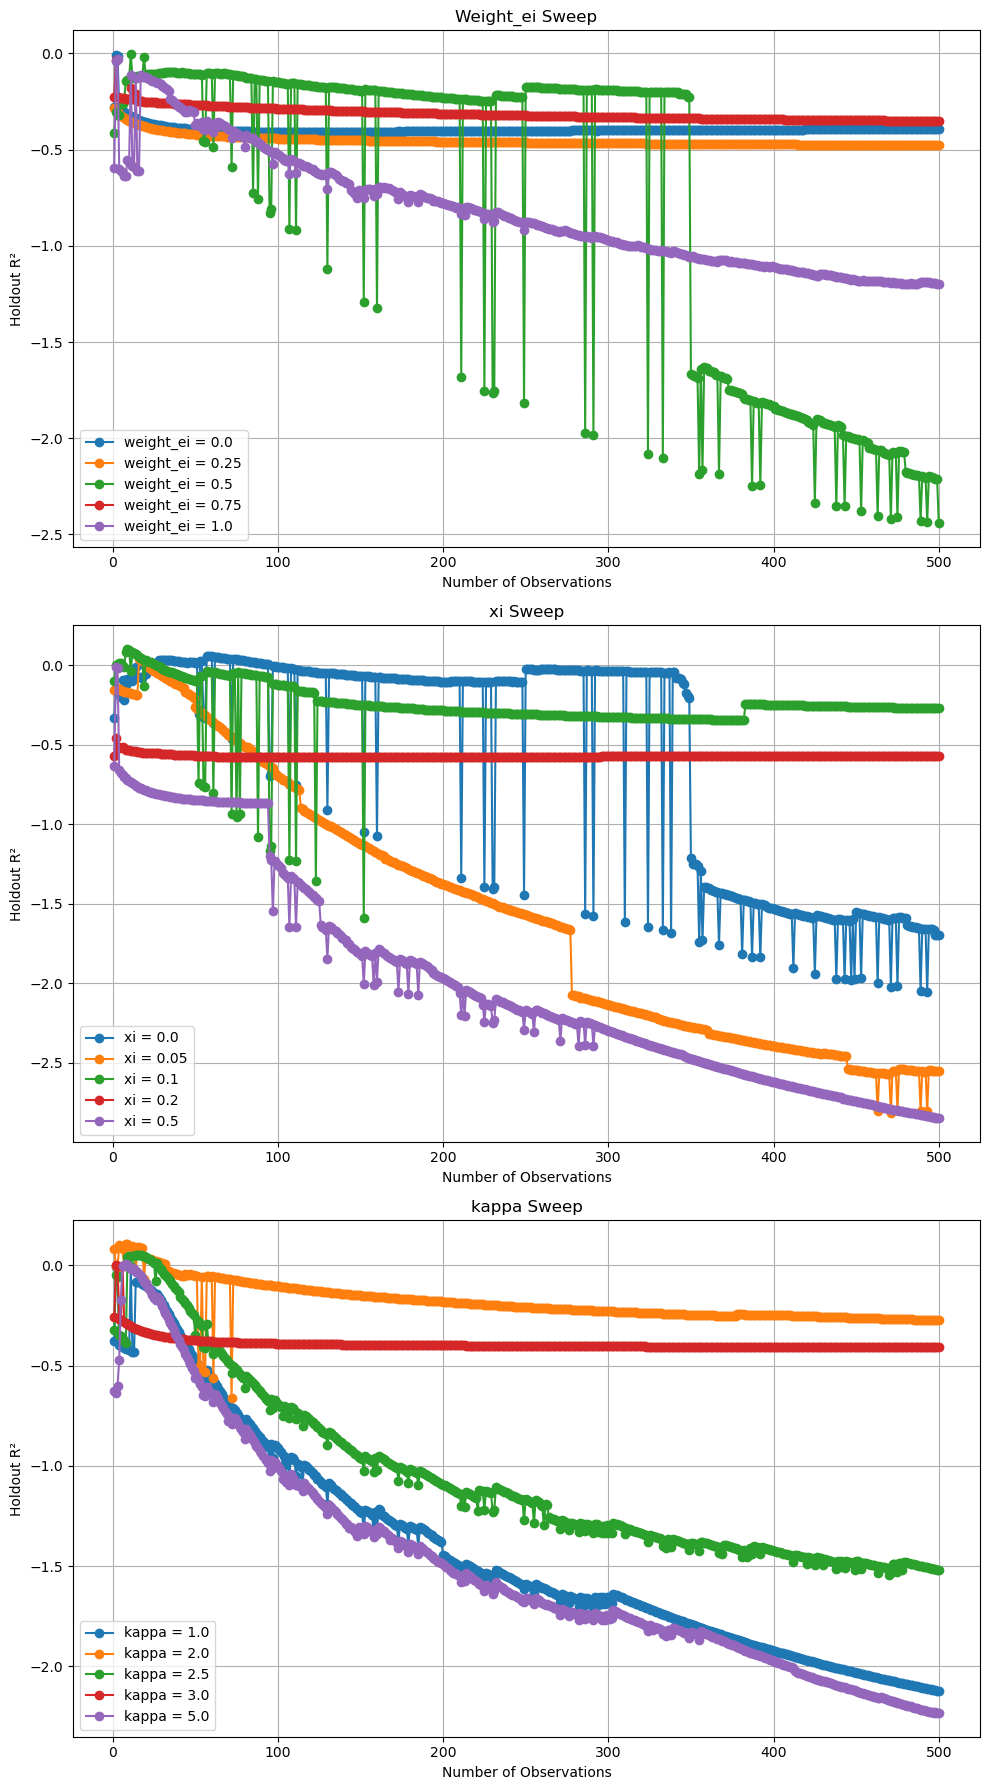

In [289]:
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot for weight_ei sweep
for w, (iters, r2s) in results_weight.items():
    axs[0].plot(iters, r2s, marker='o', linestyle='-', label=f"weight_ei = {w}")
axs[0].set_xlabel("Number of Observations")
axs[0].set_ylabel("Holdout R²")
axs[0].set_title("Weight_ei Sweep")
axs[0].legend()
axs[0].grid(True)

# Plot for xi sweep
for xi_val, (iters, r2s) in results_xi.items():
    axs[1].plot(iters, r2s, marker='o', linestyle='-', label=f"xi = {xi_val}")
axs[1].set_xlabel("Number of Observations")
axs[1].set_ylabel("Holdout R²")
axs[1].set_title("xi Sweep")
axs[1].legend()
axs[1].grid(True)

# Plot for kappa sweep
for k, (iters, r2s) in results_kappa.items():
    axs[2].plot(iters, r2s, marker='o', linestyle='-', label=f"kappa = {k}")
axs[2].set_xlabel("Number of Observations")
axs[2].set_ylabel("Holdout R²")
axs[2].set_title("kappa Sweep")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()
